# Assignment \#3: Bronsted Plot

This notebook explores the data used for assignment #3 and plots the data in a Bronsted Plot. The plots are used in the exploration docume nt for this assignment.

## Setup Tools and Read Data Table

Here the data table is read in and processed. Also the libraries are imported and any functions defined

In [38]:
# Install packages only if needed
# Coogle Colab does not include every Python package
#   
try:                  # if the package exists import it, otherwise install it
    import lmfit
except ImportError:
    !pip -q install lmfit
    import lmfit

try:
    import uncertainties
except ImportError:
    !pip -q install uncertainties
    import uncertainties

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import linregress
from scipy.optimize import curve_fit

import uncertainties as un
from uncertainties import unumpy as unp

from matplotlib.ticker import FormatStrFormatter
from scipy.stats import t

from pathlib import Path

Path("plots").mkdir(exist_ok=True)
#Path("data").mkdir(exist_ok=True)

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

#if IN_COLAB and not Path("data/3c.csv").exists():
#    !wget -q -O data/3c.csv https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/notebooks/M11_Plot_Recommendations/3c.csv

if IN_COLAB and not Path("tufte.mplstyle").exists():
    !wget -q https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/styles/tufte.mplstyle
if IN_COLAB and not Path("data").exists():
    !wget -q https://raw.github.com/blinkletter/Chem4410Webbook/main/book/notebooks/M10_Ester_Carbamate_pH-Rate_Profile/data.zip
    !unzip -q data.zip

plt.rcdefaults()

print("Setup complete")


Setup complete


## Read Data

Read the data in from the csv text file.

In [39]:
### READ DATA

data_file = "data/Data2All_labeled.csv"   

df = pd.read_csv(data_file, 
             delimiter = ",", 
             skipinitialspace=True, 
 #            index_col="pH", 
             comment = "#") 

display(df)


,NUMBER,ACID,k,Ka,p,q,label
0,1,propionic,18.00000,1.350000e-05,1,2,carb. acid
1,2,acetic,19.20000,1.760000e-05,1,2,carb. acid
2,3,beta-phenylpropionic,23.00000,2.190000e-05,1,2,carb. acid
3,4,trimethylacetic,23.60000,9.400000e-06,1,2,carb. acid
4,5,crotonic,28.70000,2.300000e-05,1,2,carb. acid
...,...,...,...,...,...,...,...
58,59,saccharine,2220.00000,2.500000e-02,1,1,alkane
59,60,nitromethane,0.00084,5.800000e-10,3,1,alkane
60,61,1-nitropropane,0.00260,1.050000e-09,2,1,alkane
61,62,nitroethane,0.00280,2.500000e-09,2,1,alkane


## Plot Data

This code will quickly plot the data. We idenify the columns we want to use for $x$ and $y$ and then call the plot function.

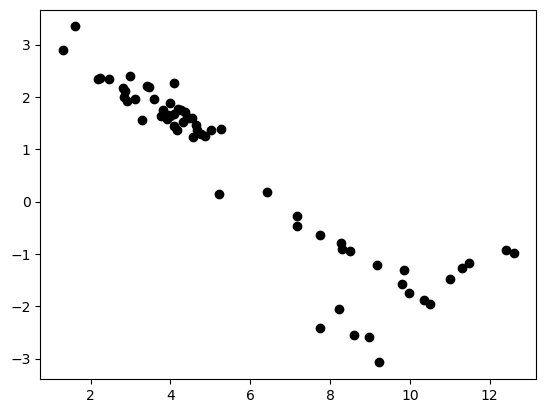

In [40]:
x = -np.log10(df["Ka"])
#y = np.log10(df["k1 (10-5 hr-1)"] *1E-5)
y = np.log10(df["k"])

plt.plot(x,y, "ko")
plt.show()


In [41]:
def bronsted(pKa, alpha, logk0):
    """
    Bronsted equation: log(k) = -alpha * pKa + logk0
    """
    return -alpha * pKa + logk0

mod = lmfit.Model(bronsted) 

# Set parameters - here i also set minimims so that no negative values are encountered in the fit
pars = mod.make_params(alpha = dict(value = 0.5), 
                       logk0 =  dict(value = 1),
                      )

# use the .fit method on the model object to perform the curve fit
result = mod.fit(y, pars, pKa=x)   
print(result.fit_report())

[[Model]]
    Model(bronsted)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 63
    # variables        = 2
    chi-square         = 28.8075463
    reduced chi-square = 0.47225486
    Akaike info crit   = -45.2973331
    Bayesian info crit = -41.0110636
    R-squared          = 0.83375022
[[Variables]]
    alpha:  0.51108537 +/- 0.02922073 (5.72%) (init = 0.5)
    logk0:  3.59101153 +/- 0.19023204 (5.30%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(alpha, logk0) = +0.8904


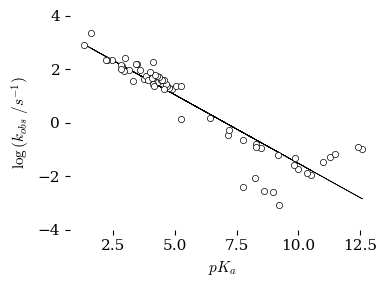

[ 1.10219637  1.16106262  1.20958069  1.02185072  1.22045849  1.38742598
  1.3319036   1.67340556  1.55537554  1.57769183  1.64250915  1.99684099
  2.12924558  2.14922792  2.33959345  2.45172661  2.92607414  1.50262157
  1.5908073   1.26804924  1.30590627  1.50611287  1.36088434  1.4065875
  1.4544416   1.55537554  2.0982238   2.14775309  1.82346328  1.85045539
  2.47322355  2.07068888 -1.77275277 -1.69708018 -1.50690871 -1.42256642
 -1.44515826 -1.10098525 -0.75058203 -0.63859    -0.36720538 -0.0721883
 -0.0738264   0.31549842  0.90288785  1.75875686  1.49989809 -2.18477956
 -2.27700802 -2.84971696 -2.75677936 -2.03092754 -0.61478561  0.9184705
 -0.65152345  1.25604839  1.46750193  1.91683685  2.77222211 -1.12966529
 -0.99792725 -0.80537548 -0.36720538]


In [42]:
y_fit = y1 = result.eval(pKa = x)


######################
### Plots - NEW STYLED PLOTTING SECTION
######################

plt.rcdefaults()

style = "tufte.mplstyle"
#style = "S2_classic2.mplstyle"
style_name = style
plt.style.use(style_name)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[4,3])

# Settings for plot
ax.set(
#          title = Title,       
          ylabel=r"$\log{(k_{obs}\ /s^{-1})}$",                
          xlabel=r"$pK_a$ ", 
#          xlim=[0, np.max(x) + np.max(x) * 0.1],                  
          ylim=[-4,4]
#          xticks = [1,3,5,7],
#          yticks = [0,-1,-2,-3],
       )

### Data graphics
ax.scatter(x, y, marker = "o", s = 20, 
              color = "white", edgecolors = "black", 
              linewidths=0.5, zorder = 4) 

ax.plot(x,y_fit, 
           marker = None, color = "black", 
           linewidth=0.5, zorder = 0)




################################################
### Output Plot
################################################

name = "plot1"

# Plot as .pdf
plt.savefig(f"plots/{name}.pdf")

### Set face of plot to transparent
ax.patch.set_facecolor([0, 0, 0, 0])  

# Plot as .png with transparent background
plt.savefig(f"plots/{name}.png", dpi=600, 
            facecolor = [0, 0, 0, 0],
        )
# display plot in notebook
plt.show()
print(y_fit)

In [43]:
# line fit
x_fit = np.linspace(np.min(x)-0.1, np.max(x)+0.1, 50)     # make an array of 50 points that span the data range
y_fit = result.eval(pKa=x_fit)                      # the line of the line fit

# confidence interval
y_err = result.eval_uncertainty(pKa=x_fit, sigma=2) # the 95% confidence interval
ci_upper = y_fit + y_err
ci_lower = y_fit - y_err

# Prediction interval

se = result.eval_uncertainty(pKa=x_fit, sigma=1)  # standard error of the fit
mse = result.redchi                             # reduced chi-squared value from the fit (mean squared error)
se_pred = np.sqrt(se**2 + mse)

dof = result.ndata - result.nvarys # degrees of freedom = number of data points - number of fitted parameters
tval = t.ppf(0.975,dof)            # two-tailed t-value for 95% confidence interval
pi = tval * se_pred

pi_lower = y_fit - pi
pi_upper = y_fit + pi

[[Model]]
    Model(bronsted)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 63
    # variables        = 2
    chi-square         = 28.8075463
    reduced chi-square = 0.47225486
    Akaike info crit   = -45.2973331
    Bayesian info crit = -41.0110636
    R-squared          = 0.83375022
[[Variables]]
    alpha:  0.51108537 +/- 0.02922073 (5.72%) (init = 0.5)
    logk0:  3.59101153 +/- 0.19023204 (5.30%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(alpha, logk0) = +0.8904


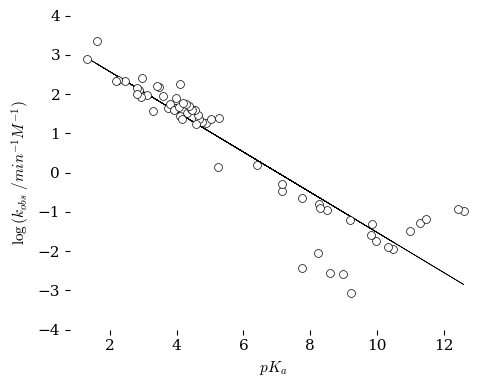

In [56]:
### READ DATA

data_file = "data/Data2All_labeled.csv"   

df = pd.read_csv(data_file, 
             delimiter = ",", 
             skipinitialspace=True, 
 #            index_col="pH", 
             comment = "#") 

x = -np.log10(df["Ka"])
#y = np.log10(df["k1 (10-5 hr-1)"] *1E-5)
y = np.log10(df["k"])

def bronsted(pKa, alpha, logk0):
    """
    Bronsted equation: log(k) = -alpha * pKa + logk0
    """
    return -alpha * pKa + logk0

mod = lmfit.Model(bronsted) 

# Set parameters - here i also set minimims so that no negative values are encountered in the fit
pars = mod.make_params(alpha = dict(value = 0.5), 
                       logk0 =  dict(value = 1),
                      )

# use the .fit method on the model object to perform the curve fit
result = mod.fit(y, pars, pKa=x)   
print(result.fit_report())


y_fit = y1 = result.eval(pKa = x)


######################
### Plots - NEW STYLED PLOTTING SECTION
######################

plt.rcdefaults()

style = "tufte.mplstyle"
#style = "S2_classic2.mplstyle"
style_name = style
plt.style.use(style_name)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,4])

# Settings for plot
ax.set(
#          title = Title,       
          ylabel=r"$\log{(k_{obs}\ /min^{-1}M^{-1})}$",                
          xlabel=r"$pK_a$ ", 
#          xlim=[np.min(x)-0.2, np.max(x)+0.2],                  
          xlim=[0.8, 13],                  
          ylim=[-4,4]
#          xticks = [1,3,5,7],
#          yticks = [0,-1,-2,-3],
       )

### Data graphics
ax.scatter(x, y, marker = "o", s = 32, 
              color = "white", edgecolors = "black", 
              linewidths=0.5, zorder = 4) 
if 1:
    ax.plot(x,y_fit, 
           marker = None, color = "black", 
           linewidth=0.5, zorder = 3)

if 0:
    ax.fill_between(
        x_fit, ci_lower, ci_upper,
        linewidth = 0,
        facecolor="gray", 
        edgecolor = "gray", 
        alpha=0.20,
        label="95% Confidence Band",
        zorder = 2,
        )



################################################
### Output Plot
################################################

name = "plot2"

# Plot as .pdf
plt.savefig(f"plots/{name}.pdf")

### Set face of plot to transparent
ax.patch.set_facecolor([0, 0, 0, 0])  

# Plot as .png with transparent background
plt.savefig(f"plots/{name}.png", dpi=600, 
            facecolor = [0, 0, 0, 0],
        )
# display plot in notebook
plt.show()


[[Model]]
    Model(bronsted)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 47
    # variables        = 2
    chi-square         = 2.23250241
    reduced chi-square = 0.04961116
    Akaike info crit   = -139.210151
    Bayesian info crit = -135.509856
    R-squared          = 0.97451527
[[Variables]]
    alpha:  0.52988739 +/- 0.01277389 (2.41%) (init = 0.5)
    logk0:  3.64437976 +/- 0.06983314 (1.92%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(alpha, logk0) = +0.8852


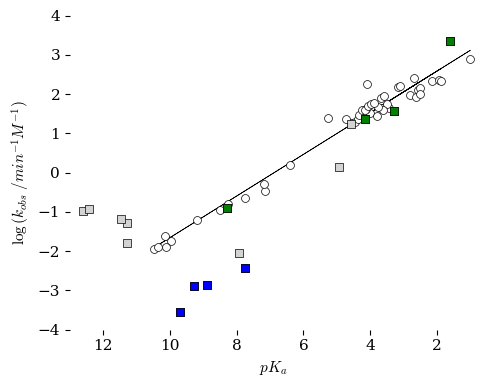

In [75]:
### READ DATA

data_file = "data/Data2All_labeled.csv"   

df = pd.read_csv(data_file, 
             delimiter = ",", 
             skipinitialspace=True, 
 #            index_col="pH", 
             comment = "#") 

df["k"] = df["k"]/df["p"]
df["Ka"] = df["Ka"]*df["q"]/df["p"]

selected_df = df[
        df["label"].isin(["carb. acid", "mp-benz. acid", "o-benz. acid", "phenol"])
]

x = -np.log10(selected_df["Ka"])
#y = np.log10(selected_df["k1 (10-5 hr-1)"] *1E-5)
y = np.log10(selected_df["k"])

def bronsted(pKa, alpha, logk0):
    """
    Bronsted equation: log(k) = -alpha * pKa + logk0
    """
    return -alpha * pKa + logk0

mod = lmfit.Model(bronsted) 

# Set parameters - here i also set minimims so that no negative values are encountered in the fit
pars = mod.make_params(alpha = dict(value = 0.5), 
                       logk0 =  dict(value = 1),
                      )

# use the .fit method on the model object to perform the curve fit
result = mod.fit(y, pars, pKa=x)   
print(result.fit_report())

y_fit = y1 = result.eval(pKa = x)


######################
### Plots - NEW STYLED PLOTTING SECTION
######################

plt.rcdefaults()

style = "tufte.mplstyle"
#style = "S2_classic2.mplstyle"
style_name = style
plt.style.use(style_name)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,4])

# Settings for plot
ax.set(
#          title = Title,       
          ylabel=r"$\log{(k_{obs}\ /min^{-1}M^{-1})}$",                
          xlabel=r"$pK_a$ ", 
          xlim=[13, 0.8],                  
          ylim=[-4,4]
#          xticks = [1,3,5,7],
#          yticks = [0,-1,-2,-3],
       )

### Data graphics
ax.scatter(x, y, marker = "o", s = 32, 
              color = "white", edgecolors = "black", 
              linewidths=0.5, zorder = 4) 
if 1:
    ax.plot(x,y_fit, 
           marker = None, color = "black", 
           linewidth=0.5, zorder = 3)

if 0:
    ax.fill_between(
        x_fit, ci_lower, ci_upper,
        linewidth = 0,
        facecolor="gray", 
        edgecolor = "gray", 
        alpha=0.20,
        label="95% Confidence Band",
        zorder = 2,
        )

################################################

if 1:
    selected_df = df[
        ~df["label"].isin(["carb. acid", "mp-benz. acid", "o-benz. acid", "phenol"])
        ]

    x = -np.log10(selected_df["Ka"])
    #y = np.log10(selected_df["k1 (10-5 hr-1)"] *1E-5)
    y = np.log10(selected_df["k"])

    ax.scatter(x, y, marker = "s", s = 32, 
                  color = "lightgray", edgecolors = "black", 
                  linewidths=0.5, zorder = 4) 

if 1:
    selected_df = df[
        df["label"].isin(["alkane"])
    ]

    x = -np.log10(selected_df["Ka"])
    #y = np.log10(selected_df["k1 (10-5 hr-1)"] *1E-5)
    y = np.log10(selected_df["k"])

    ax.scatter(x, y, marker = "s", s = 32, 
                  color = "blue", edgecolors = "black", 
                  linewidths=0.5, zorder = 4) 

if 1:
    selected_df = df[
        df["label"].isin(["other"])
    ]

    x = -np.log10(selected_df["Ka"])
    #y = np.log10(selected_df["k1 (10-5 hr-1)"] *1E-5)
    y = np.log10(selected_df["k"])

    ax.scatter(x, y, marker = "s", s = 32, 
                  color = "green", edgecolors = "black", 
                  linewidths=0.5, zorder = 4) 

################################################
### Output Plot
################################################

name = "plot3"

# Plot as .pdf
plt.savefig(f"plots/{name}.pdf")

### Set face of plot to transparent
ax.patch.set_facecolor([0, 0, 0, 0])  

# Plot as .png with transparent background
plt.savefig(f"plots/{name}.png", dpi=600, 
            facecolor = [0, 0, 0, 0],
        )
# display plot in notebook
plt.show()


In [46]:
df

,NUMBER,ACID,k,Ka,p,q,label
0,1,propionic,18.00000,1.350000e-05,1,2,carb. acid
1,2,acetic,19.20000,1.760000e-05,1,2,carb. acid
2,3,beta-phenylpropionic,23.00000,2.190000e-05,1,2,carb. acid
3,4,trimethylacetic,23.60000,9.400000e-06,1,2,carb. acid
4,5,crotonic,28.70000,2.300000e-05,1,2,carb. acid
...,...,...,...,...,...,...,...
58,59,saccharine,2220.00000,2.500000e-02,1,1,alkane
59,60,nitromethane,0.00084,5.800000e-10,3,1,alkane
60,61,1-nitropropane,0.00260,1.050000e-09,2,1,alkane
61,62,nitroethane,0.00280,2.500000e-09,2,1,alkane


## Fit To a Model

Modify the code below to use a model and get best-fit parameters for your data.